In [1]:
print(1)

1


In [2]:
import os
os.environ['R_HOME'] = 'C:\\Program Files\\R\\R-4.4.2'  # Adjust based on your R installation
import rpy2.robjects as robjects
print("Success")


Success


In [7]:
os.environ['R_USER'] = os.path.expanduser("~")

In [2]:
# This is a new analysis based on the multi-mapping counts generated by the featureCounts using the basic annotation file.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from rpy2.robjects.packages import importr
from matplotlib import cm
from matplotlib.colors import Normalize
from scipy.spatial.distance import pdist, squareform
import mygene
from collections import Counter

In [43]:
from rpy2.robjects import r, StrVector

In [4]:
# Activate pandas2ri
pandas2ri.activate()

In [6]:
print(robjects.r("R.version.string"))

R[write to console]: In addition: 
R[write to console]: Warning messages:

R[write to console]: 1: 
R[write to console]: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
R[write to console]: 
 
R[write to console]:  library 'C:/Users/huangq/AppData/Local/R/win-library/4.4' contains no packages

R[write to console]: 2: 
R[write to console]: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
R[write to console]: 
 
R[write to console]:  library 'C:/Users/huangq/AppData/Local/R/win-library/4.4' contains no packages

R[write to console]: 3: 
R[write to console]: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
R[write to console]: 
 
R[write to console]:  library 'C:/Users/huangq/AppData/Local/R/win-library/4.4' contains no packages



['R version 4.4.2 (2024-10-31 ucrt)']


In [10]:
r('BiocManager::install("DESeq2")')

R[write to console]: Bioconductor version 3.20 (BiocManager 1.30.25), R 4.4.2 (2024-10-31 ucrt)

R[write to console]: Installing package(s) 'DESeq2'

R[write to console]: also installing the dependencies 'formatR', 'UCSC.utils', 'GenomeInfoDbData', 'zlibbioc', 'SparseArray', 'lambda.r', 'futile.options', 'GenomeInfoDb', 'XVector', 'S4Arrays', 'DelayedArray', 'futile.logger', 'snow', 'S4Vectors', 'IRanges', 'GenomicRanges', 'SummarizedExperiment', 'BiocParallel', 'locfit', 'MatrixGenerics'


R[write to console]: trying URL 'https://cloud.r-project.org/bin/windows/contrib/4.4/formatR_1.14.zip'

R[write to console]: Content type 'application/zip'
R[write to console]:  length 156158 bytes (152 KB)

R[write to console]: downloaded 152 KB


R[write to console]: trying URL 'https://bioconductor.org/packages/3.20/bioc/bin/windows/contrib/4.4/UCSC.utils_1.2.0.zip'

R[write to console]: Content type 'application/zip'
R[write to console]:  length 293438 bytes (286 KB)

R[write to console]: downlo

package 'formatR' successfully unpacked and MD5 sums checked
package 'UCSC.utils' successfully unpacked and MD5 sums checked
package 'zlibbioc' successfully unpacked and MD5 sums checked
package 'SparseArray' successfully unpacked and MD5 sums checked
package 'lambda.r' successfully unpacked and MD5 sums checked
package 'futile.options' successfully unpacked and MD5 sums checked
package 'GenomeInfoDb' successfully unpacked and MD5 sums checked
package 'XVector' successfully unpacked and MD5 sums checked
package 'S4Arrays' successfully unpacked and MD5 sums checked
package 'DelayedArray' successfully unpacked and MD5 sums checked
package 'futile.logger' successfully unpacked and MD5 sums checked
package 'snow' successfully unpacked and MD5 sums checked
package 'S4Vectors' successfully unpacked and MD5 sums checked
package 'IRanges' successfully unpacked and MD5 sums checked
package 'GenomicRanges' successfully unpacked and MD5 sums checked
package 'SummarizedExperiment' successfully unp

R[write to console]: installing the source package 'GenomeInfoDbData'


R[write to console]: trying URL 'https://bioconductor.org/packages/3.20/data/annotation/src/contrib/GenomeInfoDbData_1.2.13.tar.gz'

R[write to console]: Content type 'application/x-gzip'
R[write to console]:  length 12924272 bytes (12.3 MB)

R[write to console]: downloaded 12.3 MB


R[write to console]: 

R[write to console]: 
R[write to console]: The downloaded source packages are in
	'C:\Users\huangq\AppData\Local\Temp\RtmpqCXQbV\downloaded_packages'
R[write to console]: 
R[write to console]: 

R[write to console]: Old packages: 'bit', 'bslib', 'class', 'cli', 'cluster', 'cpp11', 'curl',
  'data.table', 'foreign', 'igraph', 'jsonlite', 'KernSmooth', 'leidenbase',
  'MASS', 'Matrix', 'nlme', 'nnet', 'openssl', 'parallelly', 'purrr', 'R6',
  'RcppArmadillo', 'RcppTOML', 'reticulate', 'rpart', 'Seurat', 'sp',
  'spatial', 'spatstat.univar', 'survival', 'tinytex', 'uwot', 'xfun', 'zoo'



Update all/some/none? [a/s/n]: 

 a



  There is a binary version available but the source version is later:
           binary   source needs_compilation
reticulate 1.41.0 1.41.0.1              TRUE

  Binaries will be installed


R[write to console]: trying URL 'https://cloud.r-project.org/bin/windows/contrib/4.4/bit_4.6.0.zip'

R[write to console]: Content type 'application/zip'
R[write to console]:  length 637119 bytes (622 KB)

R[write to console]: downloaded 622 KB


R[write to console]: trying URL 'https://cloud.r-project.org/bin/windows/contrib/4.4/bslib_0.9.0.zip'

R[write to console]: Content type 'application/zip'
R[write to console]:  length 5924524 bytes (5.7 MB)

R[write to console]: downloaded 5.7 MB


R[write to console]: trying URL 'https://cloud.r-project.org/bin/windows/contrib/4.4/class_7.3-23.zip'

R[write to console]: Content type 'application/zip'
R[write to console]:  length 99790 bytes (97 KB)

R[write to console]: downloaded 97 KB


R[write to console]: trying URL 'https://cloud.r-project.org/bin/windows/contrib/4.4/cli_3.6.4.zip'

R[write to console]: Content type 'application/zip'
R[write to console]:  length 1393375 bytes (1.3 MB)

R[write to console]: downloaded 1.3 MB


R[write to c

package 'bit' successfully unpacked and MD5 sums checked
package 'bslib' successfully unpacked and MD5 sums checked
package 'class' successfully unpacked and MD5 sums checked
package 'cli' successfully unpacked and MD5 sums checked
package 'cluster' successfully unpacked and MD5 sums checked
package 'cpp11' successfully unpacked and MD5 sums checked
package 'curl' successfully unpacked and MD5 sums checked
package 'data.table' successfully unpacked and MD5 sums checked
package 'foreign' successfully unpacked and MD5 sums checked
package 'igraph' successfully unpacked and MD5 sums checked
package 'jsonlite' successfully unpacked and MD5 sums checked
package 'KernSmooth' successfully unpacked and MD5 sums checked
package 'leidenbase' successfully unpacked and MD5 sums checked
package 'MASS' successfully unpacked and MD5 sums checked
package 'Matrix' successfully unpacked and MD5 sums checked
package 'nlme' successfully unpacked and MD5 sums checked
package 'nnet' successfully unpacked an

In [11]:
# Import R packages
utils = importr('utils')
print(1)
base = importr('base')
print(3)
deseq2 = importr('DESeq2')
print(2)


1
3
2


# Step 1: Load and process the raw count matrix

In [12]:
# Load the multi-mapping raw count matrix
counts = pd.read_csv('gene_counts_basic_multimapping.txt', sep='\t', index_col=0, skiprows = 1) # Skip reading the first row since it is the command used to generate the file.
counts

,Chr,Start,End,Strand,Length,HUA7170A10_Aligned.sortedByCoord.out.bam,HUA7170A11_Aligned.sortedByCoord.out.bam,HUA7170A12_Aligned.sortedByCoord.out.bam,HUA7170A13_Aligned.sortedByCoord.out.bam,HUA7170A14_Aligned.sortedByCoord.out.bam,...,HUA7170A18_Aligned.sortedByCoord.out.bam,HUA7170A19_Aligned.sortedByCoord.out.bam,HUA7170A20_Aligned.sortedByCoord.out.bam,HUA7170A21_Aligned.sortedByCoord.out.bam,HUA7170A22_Aligned.sortedByCoord.out.bam,HUA7170A5_Aligned.sortedByCoord.out.bam,HUA7170A6_Aligned.sortedByCoord.out.bam,HUA7170A7_Aligned.sortedByCoord.out.bam,HUA7170A8_Aligned.sortedByCoord.out.bam,HUA7170A9_Aligned.sortedByCoord.out.bam
Geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000290825.2,chr1;chr1;chr1;chr1,11426;12010;12613;13221,11671;12227;12721;14409,+;+;+;+,1762,8,6,4,4,1,...,10,24,8,5,21,3,12,9,9,5
ENSG00000223972.6,chr1;chr1;chr1;chr1;chr1;chr1,12010;12179;12613;12975;13221;13453,12057;12227;12697;13052;13374;13670,+;+;+;+;+;+,632,2,0,0,0,0,...,0,2,0,0,2,0,0,0,0,0
ENSG00000310526.1,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;c...,14361;14364;14400;14400;14404;14404;14404;1440...,14829;14829;14787;14829;14829;14829;15947;1482...,-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;...,4211,372,342,641,318,359,...,623,488,366,406,303,298,569,353,363,520
ENSG00000227232.6,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1,14696;14970;15796;16607;16858;17233;17606;1791...,14829;15038;15947;16765;17055;17368;17742;1806...,-;-;-;-;-;-;-;-;-;-,1380,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000278267.1,chr1,17369,17436,-,68,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000198695.2,chrM,14149,14673,-,525,16832,11969,22496,15476,12300,...,14748,19077,21062,19608,11875,14962,20316,19324,17605,16104
ENSG00000210194.1,chrM,14674,14742,-,69,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000198727.2,chrM,14747,15887,+,1141,102947,46788,51547,84370,46290,...,74417,126118,52426,42775,53444,63156,49665,116350,64459,36100


In [13]:
# Remove the columns that are not necessary
column_to_remove = ['Chr', 'Start', 'End', 'Strand', 'Length']
for column in column_to_remove:
    counts.drop(columns = [column], inplace = True)
    
# Rename the sample names of the gene counts columns
counts.rename(columns={'HUA7170A5_Aligned.sortedByCoord.out.bam': 'C3 naive', 
                       'HUA7170A6_Aligned.sortedByCoord.out.bam': 'C3 day 5', 
                       'HUA7170A7_Aligned.sortedByCoord.out.bam': 'C3 day 10', 
                       'HUA7170A8_Aligned.sortedByCoord.out.bam': 'B10 naive',
                      'HUA7170A9_Aligned.sortedByCoord.out.bam': 'B10 day 5',
                      'HUA7170A10_Aligned.sortedByCoord.out.bam': 'B10 day 10',
                      'HUA7170A11_Aligned.sortedByCoord.out.bam': 'E11 naive',
                      'HUA7170A12_Aligned.sortedByCoord.out.bam': 'E11 day 5',
                      'HUA7170A13_Aligned.sortedByCoord.out.bam': 'E11 day 10',
                      'HUA7170A14_Aligned.sortedByCoord.out.bam': 'B2 naive',
                      'HUA7170A15_Aligned.sortedByCoord.out.bam': 'B2 day 5',
                      'HUA7170A16_Aligned.sortedByCoord.out.bam': 'B2 day 10',
                      'HUA7170A17_Aligned.sortedByCoord.out.bam': 'B11 naive',
                      'HUA7170A18_Aligned.sortedByCoord.out.bam': 'B11 day 5',
                      'HUA7170A19_Aligned.sortedByCoord.out.bam': 'B11 day 10',
                      'HUA7170A20_Aligned.sortedByCoord.out.bam': 'F12 naive',
                      'HUA7170A21_Aligned.sortedByCoord.out.bam': 'F12 day 5',
                      'HUA7170A22_Aligned.sortedByCoord.out.bam': 'F12 day 10'}, 
              inplace = True)
    
counts

,B10 day 10,E11 naive,E11 day 5,E11 day 10,B2 naive,B2 day 5,B2 day 10,B11 naive,B11 day 5,B11 day 10,F12 naive,F12 day 5,F12 day 10,C3 naive,C3 day 5,C3 day 10,B10 naive,B10 day 5
Geneid,,,,,,,,,,,,,,,,,,
ENSG00000290825.2,8,6,4,4,1,16,7,8,10,24,8,5,21,3,12,9,9,5
ENSG00000223972.6,2,0,0,0,0,0,1,0,0,2,0,0,2,0,0,0,0,0
ENSG00000310526.1,372,342,641,318,359,1166,336,378,623,488,366,406,303,298,569,353,363,520
ENSG00000227232.6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
ENSG00000278267.1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000198695.2,16832,11969,22496,15476,12300,38269,18340,16397,14748,19077,21062,19608,11875,14962,20316,19324,17605,16104
ENSG00000210194.1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
ENSG00000198727.2,102947,46788,51547,84370,46290,71846,96659,86825,74417,126118,52426,42775,53444,63156,49665,116350,64459,36100


In [14]:
# Save the trimmed count matrix
counts.to_csv('gene_counts_basic_multimapping_trimmed.csv', index = True)

# Step 2: Filter the count matrix to only keep surely expressed genes

In [15]:
# Gene counts need to be more than 50 in at least 2 samples
counts_filtered = counts[(counts >= 50).sum(axis=1) >= 2]
counts_filtered

,B10 day 10,E11 naive,E11 day 5,E11 day 10,B2 naive,B2 day 5,B2 day 10,B11 naive,B11 day 5,B11 day 10,F12 naive,F12 day 5,F12 day 10,C3 naive,C3 day 5,C3 day 10,B10 naive,B10 day 5
Geneid,,,,,,,,,,,,,,,,,,
ENSG00000310526.1,372,342,641,318,359,1166,336,378,623,488,366,406,303,298,569,353,363,520
ENSG00000241860.8,159,140,400,194,118,587,221,102,275,325,117,381,157,113,250,180,104,158
ENSG00000233750.3,33,27,33,36,31,67,39,19,46,84,8,36,33,20,30,29,19,20
ENSG00000308579.1,54,32,141,88,25,323,107,42,209,201,27,110,113,26,121,69,39,112
ENSG00000268903.1,477,297,953,388,425,1598,387,436,1367,998,183,834,750,258,849,461,204,724
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000198886.2,247488,141286,378397,211769,150988,639355,239034,260991,354595,374317,223846,422748,138389,191596,367528,301363,224729,267948
ENSG00000198786.2,82899,57734,108628,77193,63368,187929,89927,82307,74659,99034,104597,93487,58351,76623,103572,97368,84941,78717
ENSG00000198695.2,16832,11969,22496,15476,12300,38269,18340,16397,14748,19077,21062,19608,11875,14962,20316,19324,17605,16104


In [16]:
# Save the filtered count matrix
counts_filtered.to_csv('gene_counts_basic_multimapping_trimmed_filtered.csv', index = True)

# Step 3: Convert Ensembl gene ids into gene symbols

In [17]:
# Get Ensembl ids from the count matrix
Ensembl_ids = counts_filtered.index.tolist()
Ensembl_ids_no_version = [Ensembl_id.split('.')[0] for Ensembl_id in Ensembl_ids] # Remove decimals in the Ensembl id

In [18]:
# Find the gene symbol by using the mygene library
mg = mygene.MyGeneInfo() # Call MyGeneInfo() class as mg
query_result = mg.querymany(Ensembl_ids_no_version, scopes='ensembl.gene', fields=['symbol'], species='human', best_match = True) # Use the querymany() function in the MyGeneInfo() class
annotations = pd.DataFrame(query_result) # Convert query_result into pandas dataframe
annotations

5 input query terms found dup hits:	[('ENSG00000308234', 2), ('ENSG00000284116', 2), ('ENSG00000275496', 2), ('ENSG00000280018', 2), ('E
2 input query terms found no hit:	['ENSG00000168078', 'ENSG00000189144']


,query,_id,_score,symbol,notfound
0,ENSG00000310526,653635,10.60157,WASH7P,NaN
1,ENSG00000241860,ENSG00000241860,32.86487,NaN,NaN
2,ENSG00000233750,100420257,10.60157,CICP27,NaN
3,ENSG00000308579,ENSG00000308579,32.86487,NaN,NaN
4,ENSG00000268903,ENSG00000268903,32.86487,NaN,NaN
...,...,...,...,...,...
17815,ENSG00000198886,4538,32.86487,ND4,NaN
17816,ENSG00000198786,4540,32.86487,ND5,NaN
17817,ENSG00000198695,4541,32.86487,ND6,NaN
17818,ENSG00000198727,4519,32.86487,CYTB,NaN


In [19]:
# Since there are queries have duplicated hit, we need to keep only the top hit.

# Find out the duplicated hits
query_count = Counter(annotations['query'])
duplicates = [query for query, count in query_count.items() if count > 1]

# Only keep the first occurrence of the duplicated queries in the annotation dataframe
Dup_query_list = []
for index in annotations.index:
    Current_query = annotations[annotations.index == index]['query'].tolist()[0]
    if Current_query in duplicates:
        if Current_query in Dup_query_list:
            annotations = annotations.drop(index = index)
        Dup_query_list.append(Current_query)
        
annotations

,query,_id,_score,symbol,notfound
0,ENSG00000310526,653635,10.60157,WASH7P,NaN
1,ENSG00000241860,ENSG00000241860,32.86487,NaN,NaN
2,ENSG00000233750,100420257,10.60157,CICP27,NaN
3,ENSG00000308579,ENSG00000308579,32.86487,NaN,NaN
4,ENSG00000268903,ENSG00000268903,32.86487,NaN,NaN
...,...,...,...,...,...
17815,ENSG00000198886,4538,32.86487,ND4,NaN
17816,ENSG00000198786,4540,32.86487,ND5,NaN
17817,ENSG00000198695,4541,32.86487,ND6,NaN
17818,ENSG00000198727,4519,32.86487,CYTB,NaN


In [20]:
annotations[annotations['symbol'] == 'POU5F1']

,query,_id,_score,symbol,notfound
5634,ENSG00000204531,5460,32.86487,POU5F1,NaN


In [21]:
# Check if there are any duplicated symbols
symbol_count = Counter(annotations['symbol'])
duplicated_symbols = [symbol for symbol, count in symbol_count.items() if count > 1]
print(len(duplicated_symbols))
print(duplicated_symbols)

37
[nan, 'Y_RNA', 'CROCCP2', 'PSEN2', 'AHSA2P', 'EMC3', 'FAM86EP', 'MATR3', 'LOC105372733', 'PARGP1', 'ANXA8', 'TMEM198B', 'GOLGA6L3P', 'SLC6A10P', 'LRRC37A2', 'ZNF826P', 'LOC102724701', 'LOC124905527', 'PLCXD1', 'GTPBP6', 'PPP2R3B', 'SHOX', 'CSF2RA', 'SLC25A6', 'LINC00106', 'ASMTL-AS1', 'ASMTL', 'AKAP17A', 'LINC02968', 'DHRSX', 'ZBED1', 'LINC03112', 'CD99P1', 'CD99', 'VAMP7', 'IL9R', 'WASH6P']


In [22]:
# Concatenate the duplicated symbols with their corresponding Ensembl IDs.
annotations['symbol'] = annotations.apply(lambda row: f"{row['symbol']} {row['query']}" 
                                        if row['symbol'] in duplicated_symbols else row['symbol'], axis=1)

In [23]:
# Check again if there are any duplicated symbols
symbol_count = Counter(annotations['symbol'])
duplicated_symbols = [symbol for symbol, count in symbol_count.items() if count > 1]
print(len(duplicated_symbols))
print(duplicated_symbols)

0
[]


In [24]:
# View an example of a duplicated symbol
annotations[annotations['symbol'].str.contains('CROCCP2')]

,query,_id,_score,symbol,notfound
234,ENSG00000291072,84809,10.60157,CROCCP2 ENSG00000291072,NaN
235,ENSG00000215908,ENSG00000215908,10.60157,CROCCP2 ENSG00000215908,NaN


In [25]:
# Replace the Ensembl ids with gene symbols
annotations['symbol'] = annotations['symbol'].fillna(annotations['query']) # Fill the symbol with corresponding query ensembl id if the symbol is NaN
counts_filtered.index = annotations['symbol'] # Replace the index of the count_filtered by gene symbols
counts_filtered

,B10 day 10,E11 naive,E11 day 5,E11 day 10,B2 naive,B2 day 5,B2 day 10,B11 naive,B11 day 5,B11 day 10,F12 naive,F12 day 5,F12 day 10,C3 naive,C3 day 5,C3 day 10,B10 naive,B10 day 5
symbol,,,,,,,,,,,,,,,,,,
WASH7P,372,342,641,318,359,1166,336,378,623,488,366,406,303,298,569,353,363,520
nan ENSG00000241860,159,140,400,194,118,587,221,102,275,325,117,381,157,113,250,180,104,158
CICP27,33,27,33,36,31,67,39,19,46,84,8,36,33,20,30,29,19,20
nan ENSG00000308579,54,32,141,88,25,323,107,42,209,201,27,110,113,26,121,69,39,112
nan ENSG00000268903,477,297,953,388,425,1598,387,436,1367,998,183,834,750,258,849,461,204,724
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ND4,247488,141286,378397,211769,150988,639355,239034,260991,354595,374317,223846,422748,138389,191596,367528,301363,224729,267948
ND5,82899,57734,108628,77193,63368,187929,89927,82307,74659,99034,104597,93487,58351,76623,103572,97368,84941,78717
ND6,16832,11969,22496,15476,12300,38269,18340,16397,14748,19077,21062,19608,11875,14962,20316,19324,17605,16104


In [35]:
counts_filtered = counts_filtered[['B2 naive', 'B11 naive', 'F12 naive', 'C3 naive', 'B10 naive', 'E11 naive', 
                                 'B2 day 5', 'B11 day 5', 'F12 day 5', 'C3 day 5', 'B10 day 5', 'E11 day 5', 
                                 'B2 day 10', 'B11 day 10', 'F12 day 10', 'C3 day 10', 'B10 day 10', 'E11 day 10']]
counts_filtered

,B2 naive,B11 naive,F12 naive,C3 naive,B10 naive,E11 naive,B2 day 5,B11 day 5,F12 day 5,C3 day 5,B10 day 5,E11 day 5,B2 day 10,B11 day 10,F12 day 10,C3 day 10,B10 day 10,E11 day 10
symbol,,,,,,,,,,,,,,,,,,
WASH7P,359,378,366,298,363,342,1166,623,406,569,520,641,336,488,303,353,372,318
nan ENSG00000241860,118,102,117,113,104,140,587,275,381,250,158,400,221,325,157,180,159,194
CICP27,31,19,8,20,19,27,67,46,36,30,20,33,39,84,33,29,33,36
nan ENSG00000308579,25,42,27,26,39,32,323,209,110,121,112,141,107,201,113,69,54,88
nan ENSG00000268903,425,436,183,258,204,297,1598,1367,834,849,724,953,387,998,750,461,477,388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ND4,150988,260991,223846,191596,224729,141286,639355,354595,422748,367528,267948,378397,239034,374317,138389,301363,247488,211769
ND5,63368,82307,104597,76623,84941,57734,187929,74659,93487,103572,78717,108628,89927,99034,58351,97368,82899,77193
ND6,12300,16397,21062,14962,17605,11969,38269,14748,19608,20316,16104,22496,18340,19077,11875,19324,16832,15476


In [36]:
# Check for missing values
print(counts_filtered.isnull().sum())

B2 naive      0
B11 naive     0
F12 naive     0
C3 naive      0
B10 naive     0
E11 naive     0
B2 day 5      0
B11 day 5     0
F12 day 5     0
C3 day 5      0
B10 day 5     0
E11 day 5     0
B2 day 10     0
B11 day 10    0
F12 day 10    0
C3 day 10     0
B10 day 10    0
E11 day 10    0
dtype: int64


In [37]:
# Save the symboled count matrix
counts_filtered.to_csv('gene_counts_basic_multimapping_trimmed_filtered_symboled.csv', index = True)

# Step 4: Plot statistics of the mapped features

In [28]:
# Load the summary file generated by the featureCount
featureCount_stat = pd.read_csv('gene_counts_basic_multimapping.txt.summary', sep='\t', index_col=0)
featureCount_stat

,HUA7170A10_Aligned.sortedByCoord.out.bam,HUA7170A11_Aligned.sortedByCoord.out.bam,HUA7170A12_Aligned.sortedByCoord.out.bam,HUA7170A13_Aligned.sortedByCoord.out.bam,HUA7170A14_Aligned.sortedByCoord.out.bam,HUA7170A15_Aligned.sortedByCoord.out.bam,HUA7170A16_Aligned.sortedByCoord.out.bam,HUA7170A17_Aligned.sortedByCoord.out.bam,HUA7170A18_Aligned.sortedByCoord.out.bam,HUA7170A19_Aligned.sortedByCoord.out.bam,HUA7170A20_Aligned.sortedByCoord.out.bam,HUA7170A21_Aligned.sortedByCoord.out.bam,HUA7170A22_Aligned.sortedByCoord.out.bam,HUA7170A5_Aligned.sortedByCoord.out.bam,HUA7170A6_Aligned.sortedByCoord.out.bam,HUA7170A7_Aligned.sortedByCoord.out.bam,HUA7170A8_Aligned.sortedByCoord.out.bam,HUA7170A9_Aligned.sortedByCoord.out.bam
Status,,,,,,,,,,,,,,,,,,
Assigned,36743110,27138474,43827571,31968783,30554431,63924162,36452549,34459200,36909376,44266559,32229958,34677144,37590828,29303291,39917668,37869473,31042248,31802771
Unassigned_Unmapped,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Unassigned_Read_Type,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Unassigned_Singleton,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Unassigned_MappingQuality,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Unassigned_Chimera,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Unassigned_FragmentLength,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Unassigned_Duplicate,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Unassigned_MultiMapping,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [31]:
# Rename the sample names of the gene counts columns
featureCount_stat.rename(columns={'HUA7170A5_Aligned.sortedByCoord.out.bam': 'C3 naive', 
                       'HUA7170A6_Aligned.sortedByCoord.out.bam': 'C3 day 5', 
                       'HUA7170A7_Aligned.sortedByCoord.out.bam': 'C3 day 10', 
                       'HUA7170A8_Aligned.sortedByCoord.out.bam': 'B10 naive',
                      'HUA7170A9_Aligned.sortedByCoord.out.bam': 'B10 day 5',
                      'HUA7170A10_Aligned.sortedByCoord.out.bam': 'B10 day 10',
                      'HUA7170A11_Aligned.sortedByCoord.out.bam': 'E11 naive',
                      'HUA7170A12_Aligned.sortedByCoord.out.bam': 'E11 day 5',
                      'HUA7170A13_Aligned.sortedByCoord.out.bam': 'E11 day 10',
                      'HUA7170A14_Aligned.sortedByCoord.out.bam': 'B2 naive',
                      'HUA7170A15_Aligned.sortedByCoord.out.bam': 'B2 day 5',
                      'HUA7170A16_Aligned.sortedByCoord.out.bam': 'B2 day 10',
                      'HUA7170A17_Aligned.sortedByCoord.out.bam': 'B11 naive',
                      'HUA7170A18_Aligned.sortedByCoord.out.bam': 'B11 day 5',
                      'HUA7170A19_Aligned.sortedByCoord.out.bam': 'B11 day 10',
                      'HUA7170A20_Aligned.sortedByCoord.out.bam': 'F12 naive',
                      'HUA7170A21_Aligned.sortedByCoord.out.bam': 'F12 day 5',
                      'HUA7170A22_Aligned.sortedByCoord.out.bam': 'F12 day 10'}, 
              inplace = True)

C:\Users\huangq\Anaconda3\envs\Python_Scanpy_v5\lib\site-packages\pandas\core\frame.py:5039: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().rename(


In [29]:
# Remove all the rows that contain only 0
featureCount_stat = featureCount_stat[(featureCount_stat != 0).any(axis=1)]

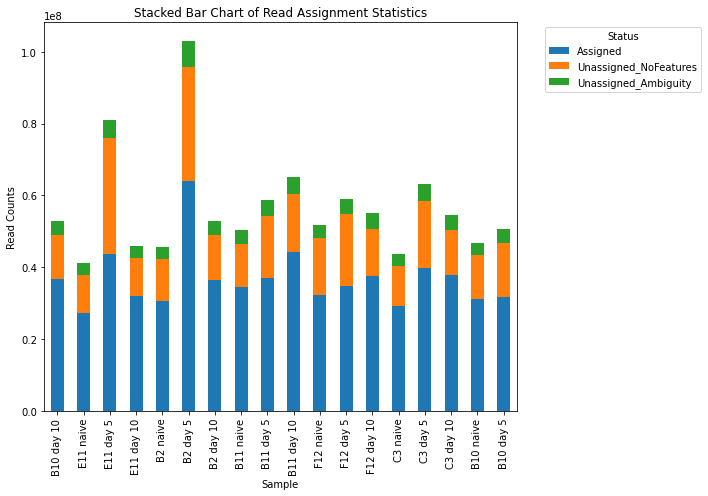

In [32]:
# Plot stacked bar chart of the assignment statistics
featureCount_stat.T.plot(kind='bar', stacked=True, figsize=(10, 7))

plt.xlabel("Sample")
plt.ylabel("Read Counts")
plt.title("Stacked Bar Chart of Read Assignment Statistics")

plt.legend(title="Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Step 5: Perform DESeq2 analysis

In [42]:
# Prepare metadata
sample_names = counts_filtered.columns
condition = ['control naive', 'control naive', 'control naive', 'knockout naive', 'knockout naive', 'knockout naive', 
            'control day 5', 'control day 5', 'control day 5', 'knockout day 5', 'knockout day 5', 'knockout day 5', 
            'control day 10', 'control day 10', 'control day 10', 'knockout day 10', 'knockout day 10', 'knockout day 10']
coldata = pd.DataFrame({'condition': condition}, index=sample_names) # Create a sample name to condition map

# Convert to R DataFrames
counts_filtered_R = pandas2ri.py2rpy(counts_filtered)
coldata_R = pandas2ri.py2rpy(coldata)

# Create DESeqDataSet
dds = deseq2.DESeqDataSetFromMatrix(countData=counts_filtered_R,
                                    colData=coldata_R,
                                    design=robjects.Formula('~ condition'))

# Run DESeq
dds = deseq2.DESeq(dds) # Counts in dds is now normalized to medium by default when running DESeq

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating size factors

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating dispersions

R[write to console]: gene-wise dispersion estimates

R[write to console]: mean-dispersion relationship

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) 

In [47]:
# Get results
#res = deseq2.results(dds)
results_naive = deseq2.results(dds, contrast=StrVector(["condition", "knockout naive", "control naive"]))
results_day_5 = deseq2.results(dds, contrast=StrVector(["condition", "knockout day 5", "control day 5"]))
results_day_10 = deseq2.results(dds, contrast=StrVector(["condition", "knockout day 10", "control day 10"]))

Result_dict = {"Naive": results_naive, 
              "Day_5": results_day_5, 
              "Day_10": results_day_10}

# Convert R DataFrame to pandas DataFrame
for name, res in Result_dict.items():
    print(name)
    res_df_r = robjects.r['as.data.frame'](res) # Convert res from the DESeq2 into R dataframe
    res_df = pandas2ri.rpy2py(res_df_r) # Convert R dataframe into pandas dataframe
    res_df.index = counts_filtered.index  # Set gene names
    res_df = res_df.rename_axis('GeneID').reset_index() # Change index name into 'GeneID', then make the index into a normal column
    globals()[f'{name}_df'] = res_df

# View results
Naive_df
Day_5_df
Day_10_df

Naive
Day_5
Day_10


,GeneID,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,WASH7P,435.021784,0.063040,0.177744,0.354667,0.722839,0.948424
1,nan ENSG00000241860,207.690701,-0.204948,0.268906,-0.762156,0.445967,0.858362
2,CICP27,32.186670,-0.457597,0.424983,-1.076741,0.281596,0.759498
3,nan ENSG00000308579,94.246903,-0.790661,0.315992,-2.502156,0.012344,0.238582
4,nan ENSG00000268903,608.638480,-0.503366,0.322131,-1.562613,0.118144,0.581442
...,...,...,...,...,...,...,...
17809,ND4,272422.517216,0.205953,0.241587,0.852501,0.393936,0.832502
17810,ND5,86790.014663,0.222051,0.196828,1.128145,0.259259,0.744215
17811,ND6,17494.037394,0.227004,0.202284,1.122201,0.261777,0.745530
17812,CYTB,68856.451456,0.313296,0.276981,1.131109,0.258009,0.744095


In [48]:
Naive_df

,GeneID,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,WASH7P,435.021784,-0.015086,0.177971,-0.084766,0.932447,1.000000
1,nan ENSG00000241860,207.690701,0.209636,0.278124,0.753751,0.450999,0.992901
2,CICP27,32.186670,0.312102,0.461333,0.676521,0.498710,NaN
3,nan ENSG00000308579,94.246903,0.171580,0.358851,0.478137,0.632552,1.000000
4,nan ENSG00000268903,608.638480,-0.322649,0.325445,-0.991411,0.321485,0.966813
...,...,...,...,...,...,...,...
17809,ND4,272422.517216,-0.068897,0.241590,-0.285180,0.775507,1.000000
17810,ND5,86790.014663,-0.075789,0.196831,-0.385046,0.700204,1.000000
17811,ND6,17494.037394,-0.045226,0.202298,-0.223560,0.823100,1.000000
17812,CYTB,68856.451456,0.039827,0.276997,0.143782,0.885672,1.000000


In [49]:
Day_5_df

,GeneID,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,WASH7P,435.021784,-0.060486,0.173129,-0.349370,0.726812,0.915027
1,nan ENSG00000241860,207.690701,-0.425838,0.264330,-1.611012,0.107177,0.453035
2,CICP27,32.186670,-0.641255,0.431200,-1.487139,0.136978,0.499594
3,nan ENSG00000308579,94.246903,-0.521413,0.306841,-1.699292,0.089264,0.418810
4,nan ENSG00000268903,608.638480,-0.400155,0.320305,-1.249292,0.211558,0.588088
...,...,...,...,...,...,...,...
17809,ND4,272422.517216,-0.272970,0.241583,-1.129922,0.258509,0.635606
17810,ND5,86790.014663,-0.015589,0.196821,-0.079203,0.936871,0.982054
17811,ND6,17494.037394,-0.025934,0.202247,-0.128231,0.897966,0.973253
17812,CYTB,68856.451456,-0.314189,0.277003,-1.134242,0.256693,0.634156


In [50]:
Day_10_df

,GeneID,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,WASH7P,435.021784,0.063040,0.177744,0.354667,0.722839,0.948424
1,nan ENSG00000241860,207.690701,-0.204948,0.268906,-0.762156,0.445967,0.858362
2,CICP27,32.186670,-0.457597,0.424983,-1.076741,0.281596,0.759498
3,nan ENSG00000308579,94.246903,-0.790661,0.315992,-2.502156,0.012344,0.238582
4,nan ENSG00000268903,608.638480,-0.503366,0.322131,-1.562613,0.118144,0.581442
...,...,...,...,...,...,...,...
17809,ND4,272422.517216,0.205953,0.241587,0.852501,0.393936,0.832502
17810,ND5,86790.014663,0.222051,0.196828,1.128145,0.259259,0.744215
17811,ND6,17494.037394,0.227004,0.202284,1.122201,0.261777,0.745530
17812,CYTB,68856.451456,0.313296,0.276981,1.131109,0.258009,0.744095


In [51]:
# Save the DESeq2 result
Naive_df.to_csv("Naive_df.csv", index=False)
Day_5_df.to_csv("Day_5_df.csv", index=False)
Day_10_df.to_csv("Day_10_df.csv", index=False)

# Step 6: Perform PCA analysis

In [52]:
# Perform variance stabilization for the normalized counts
vsd = deseq2.vst(dds, blind=False)

# Extract the transformed counts
vsd_counts_array = robjects.r['assay'](vsd) # Use assay function in R to conver the vsd into assay
vsd_counts = pd.DataFrame(vsd_counts_array, index=counts_filtered.index, columns=counts_filtered.columns) # Create a new pandas dataframe by using the assay
vsd_counts

,B2 naive,B11 naive,F12 naive,C3 naive,B10 naive,E11 naive,B2 day 5,B11 day 5,F12 day 5,C3 day 5,B10 day 5,E11 day 5,B2 day 10,B11 day 10,F12 day 10,C3 day 10,B10 day 10,E11 day 10
symbol,,,,,,,,,,,,,,,,,,
WASH7P,8.923579,8.894342,8.929423,8.777034,8.936836,8.989217,9.621634,9.603879,9.051459,9.316333,9.492912,9.386037,8.748866,8.926380,8.636121,8.769469,8.865426,8.842633
nan ENSG00000241860,7.789795,7.602188,7.770000,7.802209,7.682072,8.041420,8.800518,8.638510,8.977231,8.385018,8.157716,8.828741,8.300789,8.476177,7.969442,8.067598,7.981038,8.308832
CICP27,6.863774,6.601329,6.329555,6.680137,6.633362,6.846638,6.956795,7.097002,6.937396,6.781918,6.701287,6.798269,6.940446,7.284466,6.851483,6.770522,6.851387,6.973230
nan ENSG00000308579,6.756229,6.988494,6.786541,6.803318,6.990411,6.937682,8.168200,8.346719,7.718018,7.700524,7.836103,7.778442,7.632577,7.996094,7.679121,7.276981,7.135428,7.585950
nan ENSG00000268903,9.120883,9.060121,8.185156,8.617325,8.308968,8.827124,10.024622,10.629279,9.942016,9.815915,9.911616,9.884512,8.909138,9.798267,9.712776,9.076767,9.155516,9.072970
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ND4,17.297849,17.975945,17.845070,17.724161,17.871882,17.353774,18.514432,18.547833,18.763700,18.394567,18.276055,18.347109,17.833873,18.167845,17.048108,18.123352,17.885959,17.858512
ND5,16.046588,16.312353,16.748165,16.403031,16.469305,16.064004,16.749009,16.301584,16.587981,16.568507,16.510037,16.547773,16.424596,16.251060,15.803795,16.494520,16.309313,16.403713
ND6,13.691067,13.992489,14.441675,14.053990,14.205421,13.802602,14.458625,13.969646,14.340641,14.225155,14.227296,14.282368,14.137774,13.883366,13.517639,14.168306,14.016719,14.092467


In [53]:
# Save the new count matrix
vsd_counts.to_csv('DESeq_vsd_basic_multimapping_counts.csv', index = True)

In [3]:
vsd_counts = pd.read_csv('DESeq_vsd_basic_multimapping_counts.csv', index_col = 0)
vsd_counts

,B2 naive,B11 naive,F12 naive,C3 naive,B10 naive,E11 naive,B2 day 5,B11 day 5,F12 day 5,C3 day 5,B10 day 5,E11 day 5,B2 day 10,B11 day 10,F12 day 10,C3 day 10,B10 day 10,E11 day 10
symbol,,,,,,,,,,,,,,,,,,
WASH7P,8.923579,8.894342,8.929423,8.777034,8.936836,8.989217,9.621634,9.603879,9.051459,9.316333,9.492912,9.386037,8.748866,8.926380,8.636121,8.769469,8.865426,8.842633
nan ENSG00000241860,7.789795,7.602188,7.770000,7.802209,7.682072,8.041420,8.800518,8.638510,8.977231,8.385018,8.157716,8.828741,8.300789,8.476177,7.969442,8.067598,7.981038,8.308832
CICP27,6.863774,6.601329,6.329555,6.680137,6.633362,6.846638,6.956795,7.097002,6.937396,6.781918,6.701287,6.798269,6.940446,7.284466,6.851483,6.770522,6.851387,6.973230
nan ENSG00000308579,6.756229,6.988494,6.786541,6.803318,6.990411,6.937682,8.168200,8.346719,7.718018,7.700524,7.836103,7.778442,7.632577,7.996094,7.679121,7.276981,7.135428,7.585950
nan ENSG00000268903,9.120883,9.060121,8.185156,8.617325,8.308968,8.827124,10.024622,10.629279,9.942016,9.815915,9.911616,9.884512,8.909138,9.798267,9.712776,9.076767,9.155516,9.072970
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ND4,17.297849,17.975945,17.845070,17.724161,17.871882,17.353774,18.514432,18.547833,18.763700,18.394567,18.276055,18.347109,17.833873,18.167845,17.048108,18.123352,17.885959,17.858512
ND5,16.046588,16.312353,16.748165,16.403031,16.469305,16.064004,16.749009,16.301584,16.587981,16.568507,16.510037,16.547773,16.424596,16.251060,15.803795,16.494520,16.309313,16.403713
ND6,13.691067,13.992489,14.441675,14.053990,14.205421,13.802602,14.458625,13.969646,14.340641,14.225155,14.227296,14.282368,14.137774,13.883366,13.517639,14.168306,14.016719,14.092467


In [4]:
# Perform PCA
pca = PCA(n_components=3)
pca_result = pca.fit_transform(vsd_counts.T)

# Prepare a DataFrame for plotting
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2', 'PC3'])
pca_df['condition'] = [
    "B2 naive", "B11 naive", "F12 naive", "C3 naive", "B10 naive", "E11 naive",
    "B2 day 5", "B11 day 5", "F12 day 5", "C3 day 5", "B10 day 5", "E11 day 5",
    "B2 day 10", "B11 day 10", "F12 day 10", "C3 day 10", "B10 day 10", "E11 day 10"]

In [7]:
print(pca.explained_variance_ratio_)

[0.53833885 0.27457905 0.06501796]


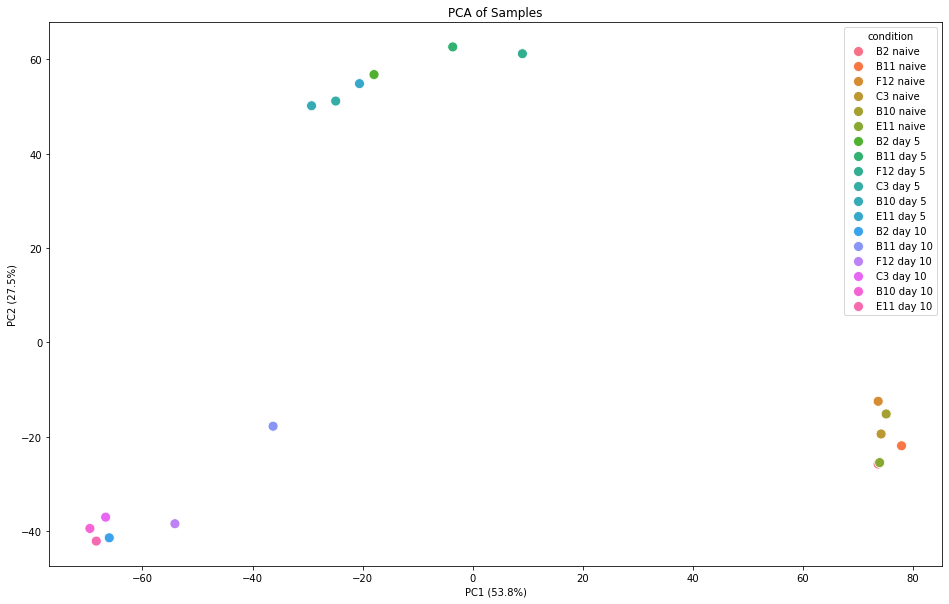

In [8]:
# Plot 2D PCA
plt.figure(figsize=(16,10))
sns.scatterplot(x='PC1', y='PC2', hue='condition', data=pca_df, s=100)
plt.title('PCA of Samples')
plt.xlabel('PC1 (53.8%)')
plt.ylabel('PC2 (27.5%)')

plt.savefig('/Bioinformatics_D/Figures/PCA 2D.pdf', bbox_inches='tight', dpi=300)
plt.savefig('/Bioinformatics_D/Figures/PCA 2D.png', bbox_inches='tight', dpi=300)
plt.show()

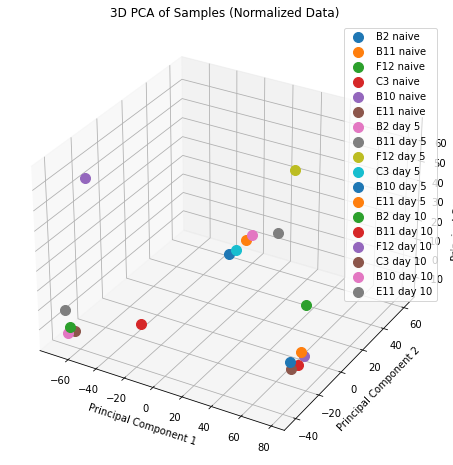

In [58]:
# Plot 3D PCA
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Map conditions to colors
conditions = pca_df['condition'].unique()
#colors = {'WT': 'blue', 'cH9': 'orange', 'cB4': 'green', 'cC3': 'red'}

# Plot each sample
for condition in conditions:
    idx = pca_df['condition'] == condition
    ax.scatter(pca_df.loc[idx, 'PC1'],
               pca_df.loc[idx, 'PC2'],
               pca_df.loc[idx, 'PC3'],
               #c=colors[condition],
               label=condition,
               s=100)

# Add labels and title
ax.set_title('3D PCA of Samples (Normalized Data)')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.legend()

# Show the plot
plt.show()

# Step 7: Sample similarity analysis

In [9]:
# Add random counts into the count matrix
Num_of_features = vsd_counts.shape[0] # Find out the total number of features in the count matrix
min_count = vsd_counts.min().min() # Find out the mininum count in the matrix
max_count = vsd_counts.max().max() # Find out the maximum count in the matrix
random_counts = np.random.uniform(min_count, max_count, size=Num_of_features).tolist() # Generate a random count list
vsd_counts_with_rand = vsd_counts
vsd_counts_with_rand['Rand'] = random_counts # Add the random count list to the 'Rand' column of the count matrix
vsd_counts_with_rand

,B2 naive,B11 naive,F12 naive,C3 naive,B10 naive,E11 naive,B2 day 5,B11 day 5,F12 day 5,C3 day 5,B10 day 5,E11 day 5,B2 day 10,B11 day 10,F12 day 10,C3 day 10,B10 day 10,E11 day 10,Rand
symbol,,,,,,,,,,,,,,,,,,,
WASH7P,8.923579,8.894342,8.929423,8.777034,8.936836,8.989217,9.621634,9.603879,9.051459,9.316333,9.492912,9.386037,8.748866,8.926380,8.636121,8.769469,8.865426,8.842633,9.427537
nan ENSG00000241860,7.789795,7.602188,7.770000,7.802209,7.682072,8.041420,8.800518,8.638510,8.977231,8.385018,8.157716,8.828741,8.300789,8.476177,7.969442,8.067598,7.981038,8.308832,8.447137
CICP27,6.863774,6.601329,6.329555,6.680137,6.633362,6.846638,6.956795,7.097002,6.937396,6.781918,6.701287,6.798269,6.940446,7.284466,6.851483,6.770522,6.851387,6.973230,10.321480
nan ENSG00000308579,6.756229,6.988494,6.786541,6.803318,6.990411,6.937682,8.168200,8.346719,7.718018,7.700524,7.836103,7.778442,7.632577,7.996094,7.679121,7.276981,7.135428,7.585950,7.305388
nan ENSG00000268903,9.120883,9.060121,8.185156,8.617325,8.308968,8.827124,10.024622,10.629279,9.942016,9.815915,9.911616,9.884512,8.909138,9.798267,9.712776,9.076767,9.155516,9.072970,8.826846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ND4,17.297849,17.975945,17.845070,17.724161,17.871882,17.353774,18.514432,18.547833,18.763700,18.394567,18.276055,18.347109,17.833873,18.167845,17.048108,18.123352,17.885959,17.858512,6.281307
ND5,16.046588,16.312353,16.748165,16.403031,16.469305,16.064004,16.749009,16.301584,16.587981,16.568507,16.510037,16.547773,16.424596,16.251060,15.803795,16.494520,16.309313,16.403713,13.011771
ND6,13.691067,13.992489,14.441675,14.053990,14.205421,13.802602,14.458625,13.969646,14.340641,14.225155,14.227296,14.282368,14.137774,13.883366,13.517639,14.168306,14.016719,14.092467,15.459136


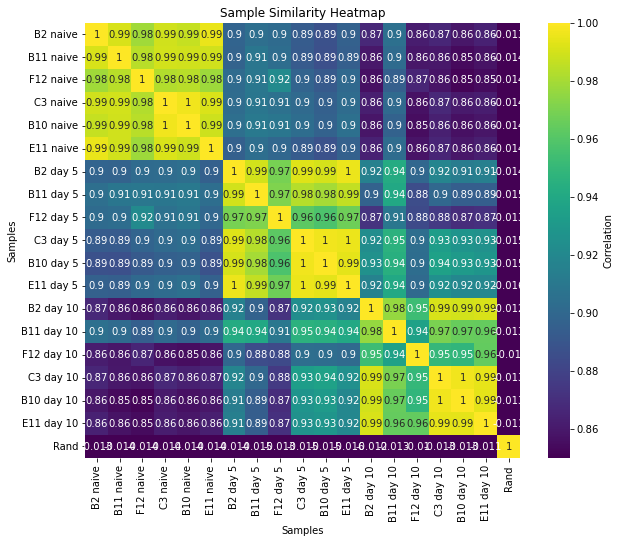

In [10]:
# Plot similarity heatmap to visualize the similarity between samples
similarity_matrix = vsd_counts_with_rand.corr(method='pearson')  # Calculate the similarity matrix by using pearson

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, cmap="viridis", square=True, cbar_kws={'label': 'Correlation'}, vmin=0.85, vmax=1)
plt.title("Sample Similarity Heatmap")
plt.xlabel("Samples")
plt.ylabel("Samples")

plt.savefig('/Bioinformatics_D/Figures/Pearson heatmap R2.pdf', bbox_inches='tight', dpi=300)
plt.savefig('/Bioinformatics_D/Figures/Pearson heatmap R2.png', bbox_inches='tight', dpi=300)
plt.show()

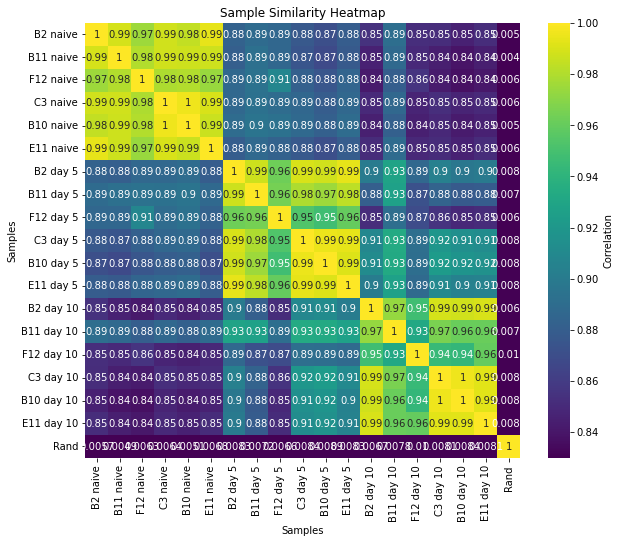

In [66]:
# Plot similarity heatmap to visualize the similarity between samples
similarity_matrix = vsd_counts_with_rand.corr(method='spearman')  # Calculate the similarity matrix by using spearman

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, cmap="viridis", square=True, cbar_kws={'label': 'Correlation'}, vmin=0.83, vmax=1)
plt.title("Sample Similarity Heatmap")
plt.xlabel("Samples")
plt.ylabel("Samples")
plt.show()

# Step 8: Plot volcano plots

In [67]:
res_df = Day_10_df

In [19]:
res_df = pd.read_csv('Day_10_DEG_df.csv')

In [20]:
res_df

,GeneID,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,WASH7P,435.021784,0.063040,0.177744,0.354667,0.722839,0.948424
1,nan ENSG00000241860,207.690701,-0.204948,0.268906,-0.762156,0.445967,0.858362
2,CICP27,32.186670,-0.457597,0.424983,-1.076741,0.281596,0.759498
3,nan ENSG00000308579,94.246903,-0.790661,0.315992,-2.502156,0.012344,0.238582
4,nan ENSG00000268903,608.638480,-0.503366,0.322131,-1.562613,0.118144,0.581442
...,...,...,...,...,...,...,...
17809,ND4,272422.517216,0.205953,0.241587,0.852501,0.393936,0.832502
17810,ND5,86790.014663,0.222051,0.196828,1.128145,0.259259,0.744215
17811,ND6,17494.037394,0.227004,0.202284,1.122201,0.261777,0.745530
17812,CYTB,68856.451456,0.313296,0.276981,1.131109,0.258009,0.744095


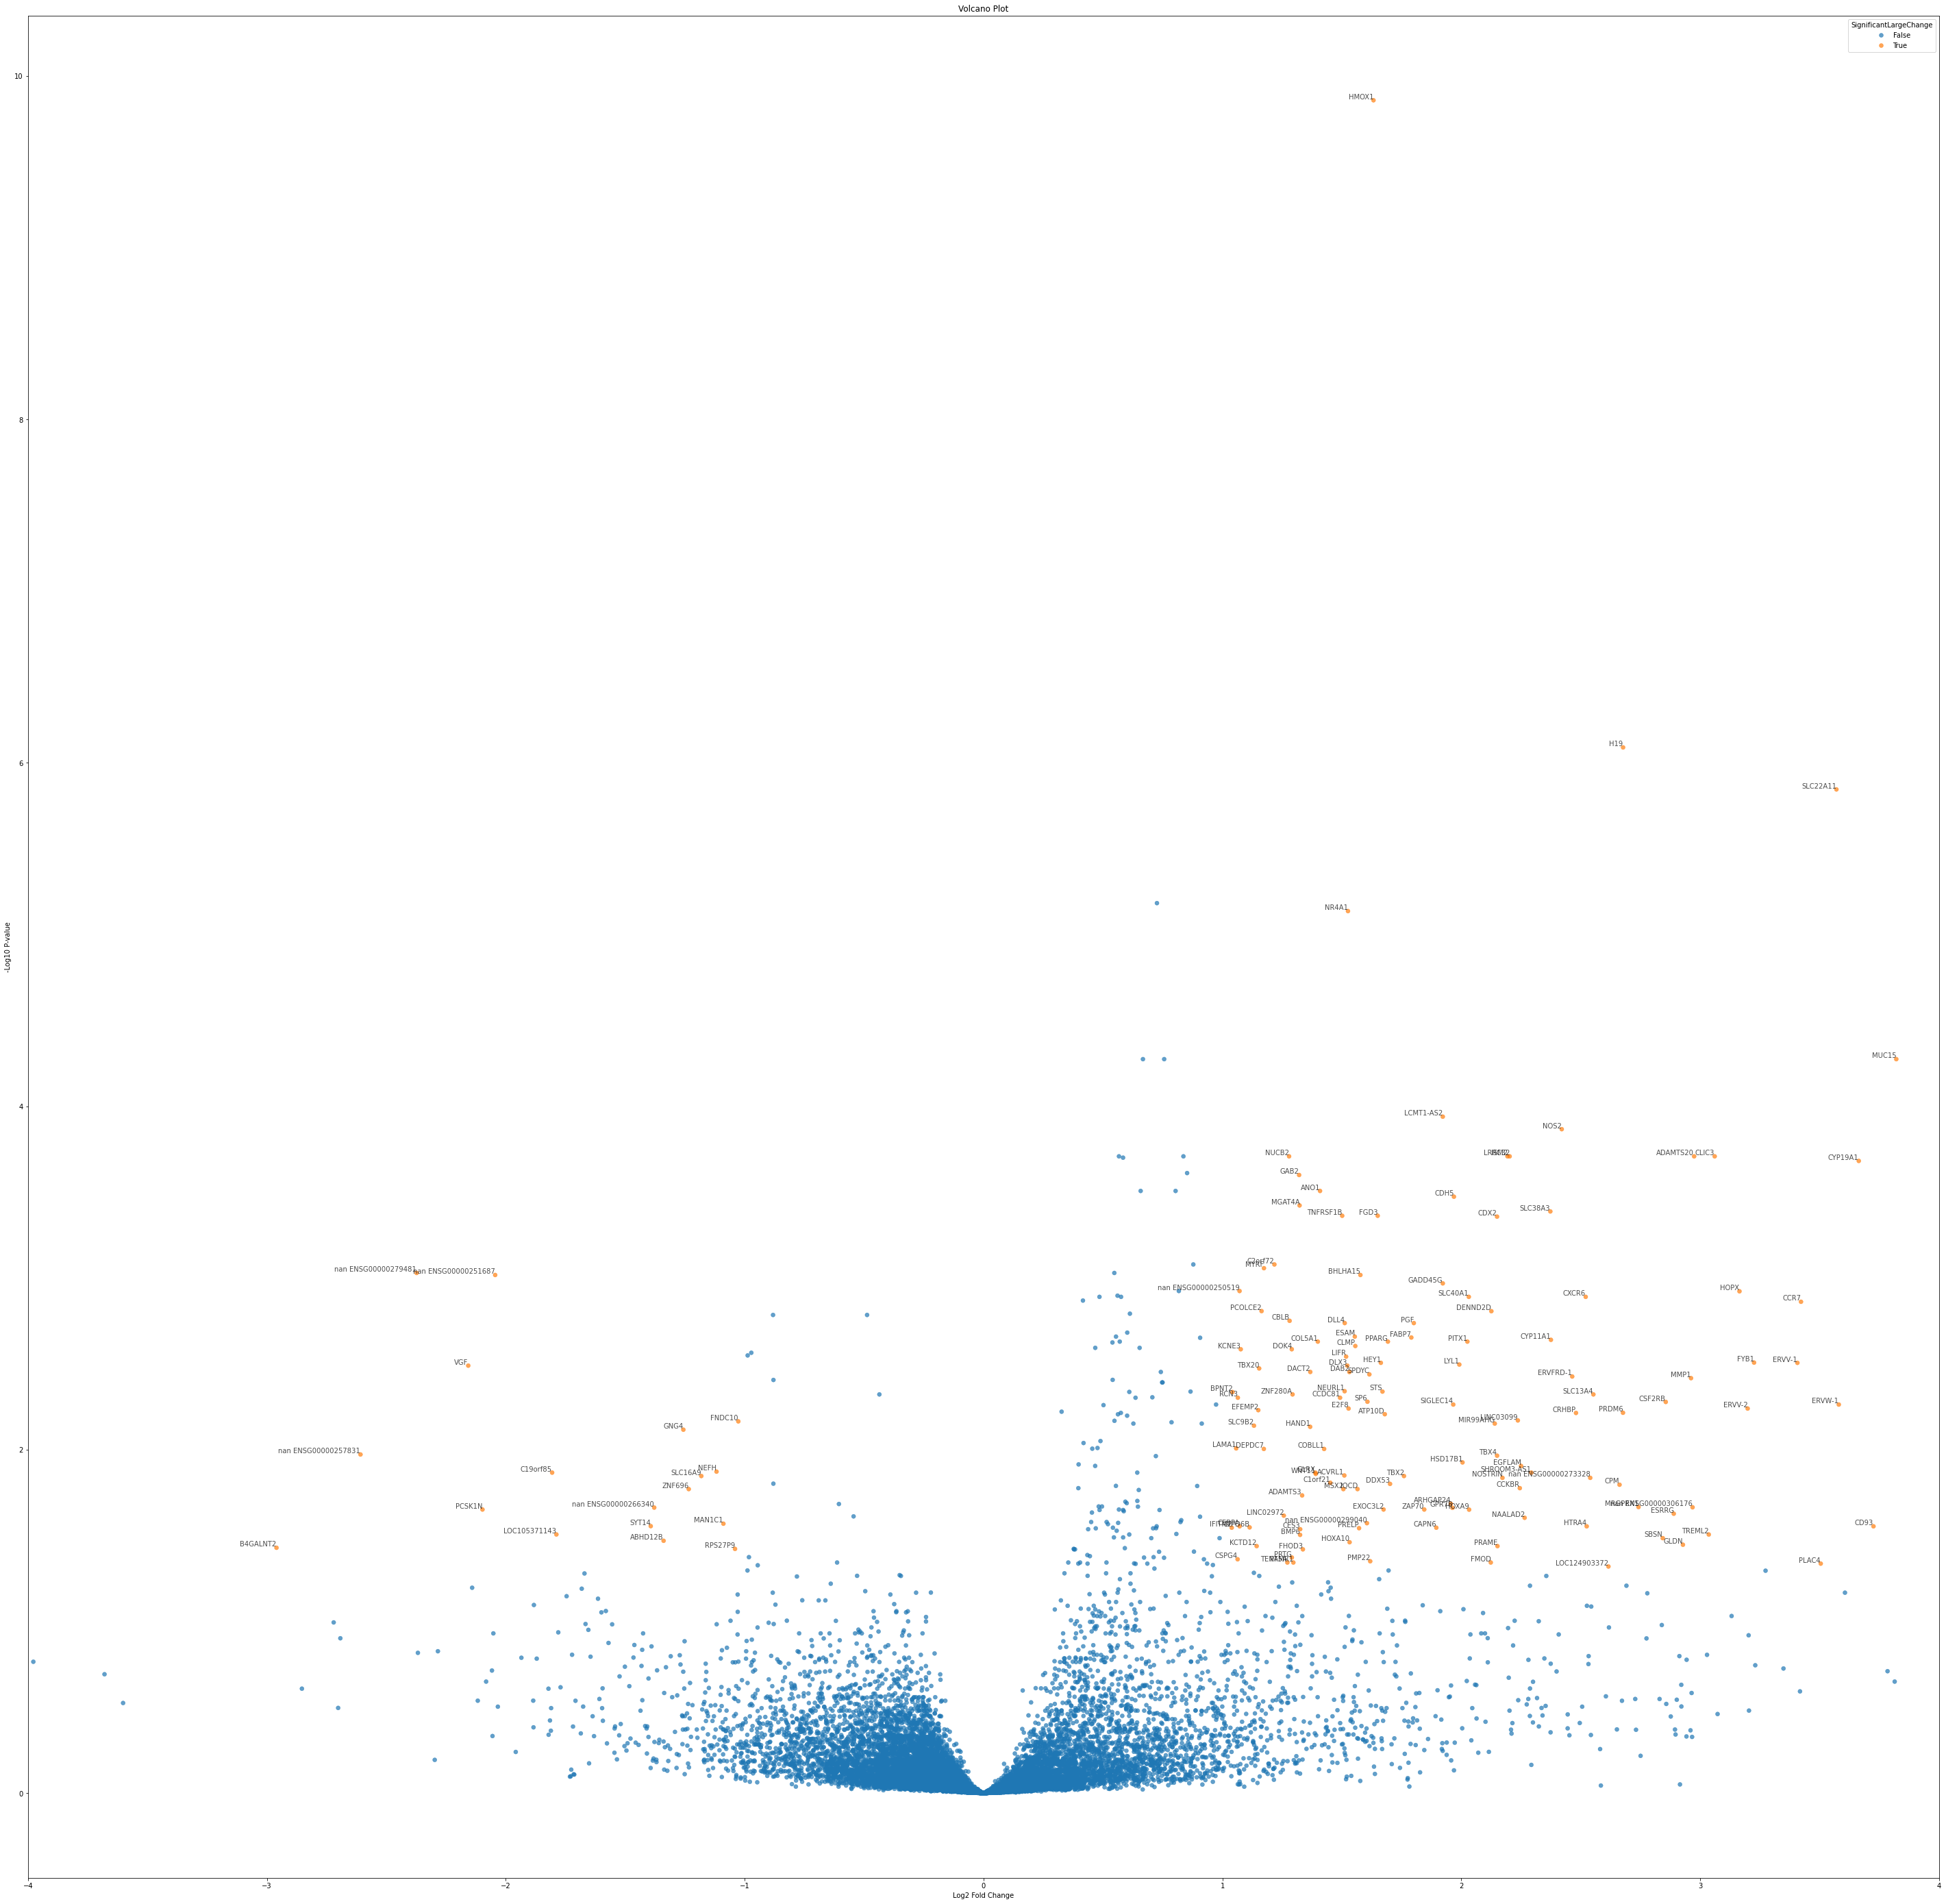

In [21]:
#Plot a large volcano plot to show all the details
res_df['significant'] = res_df['padj'] < 0.05
res_df['TwoFoldChange'] = (res_df['log2FoldChange'] >= 1) | (res_df['log2FoldChange'] <= -1)
res_df['SignificantLargeChange'] = (res_df['significant'] == True) & (res_df['TwoFoldChange'] == True)

# Volcano plot
plt.figure(figsize=(50,50))
sns.scatterplot(data=res_df, x='log2FoldChange', y=-np.log10(res_df['padj']),
                hue='SignificantLargeChange', edgecolor=None, alpha=0.7)
plt.xlim(-4, 4)
plt.title('Volcano Plot')
plt.xlabel('Log2 Fold Change')
plt.ylabel('-Log10 P-value')

for _, row in res_df[res_df['SignificantLargeChange']].iterrows():
    
    plt.text(row['log2FoldChange'], -np.log10(row['padj']), row['GeneID'], 
             ha='right', va='bottom', fontsize=10, alpha = 0.7)


plt.show()

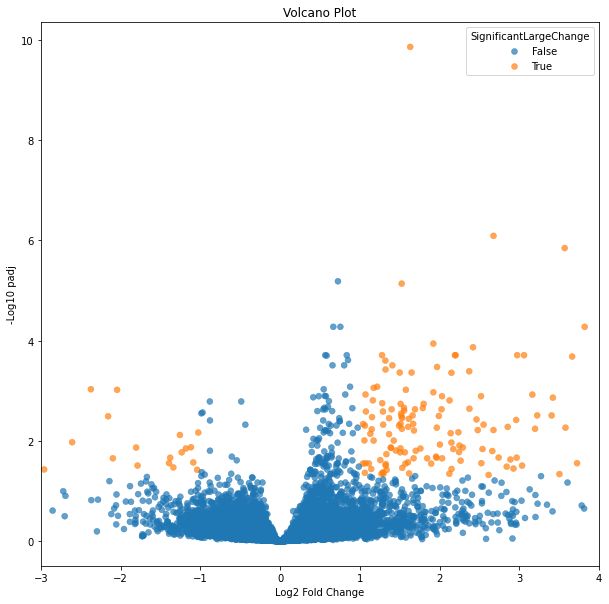

In [26]:
# Plot a small volcano plot
res_df['significant'] = res_df['padj'] < 0.05
res_df['TwoFoldChange'] = (res_df['log2FoldChange'] >= 1) | (res_df['log2FoldChange'] <= -1)
res_df['SignificantLargeChange'] = (res_df['significant'] == True) & (res_df['TwoFoldChange'] == True)

# Volcano plot
plt.figure(figsize=(10,10))
sns.scatterplot(data=res_df, x='log2FoldChange', y=-np.log10(res_df['padj']),
                hue='SignificantLargeChange', edgecolor=None, alpha=0.7)
plt.xlim(-3, 4)
plt.title('Volcano Plot')
plt.xlabel('Log2 Fold Change')
plt.ylabel('-Log10 padj')

plt.savefig('/Bioinformatics_D/Figures/Volcano_small_day10_R2.pdf', bbox_inches='tight', dpi=300)
plt.savefig('/Bioinformatics_D/Figures/Volcano_small_day10_R2.png', bbox_inches='tight', dpi=300)
plt.show()

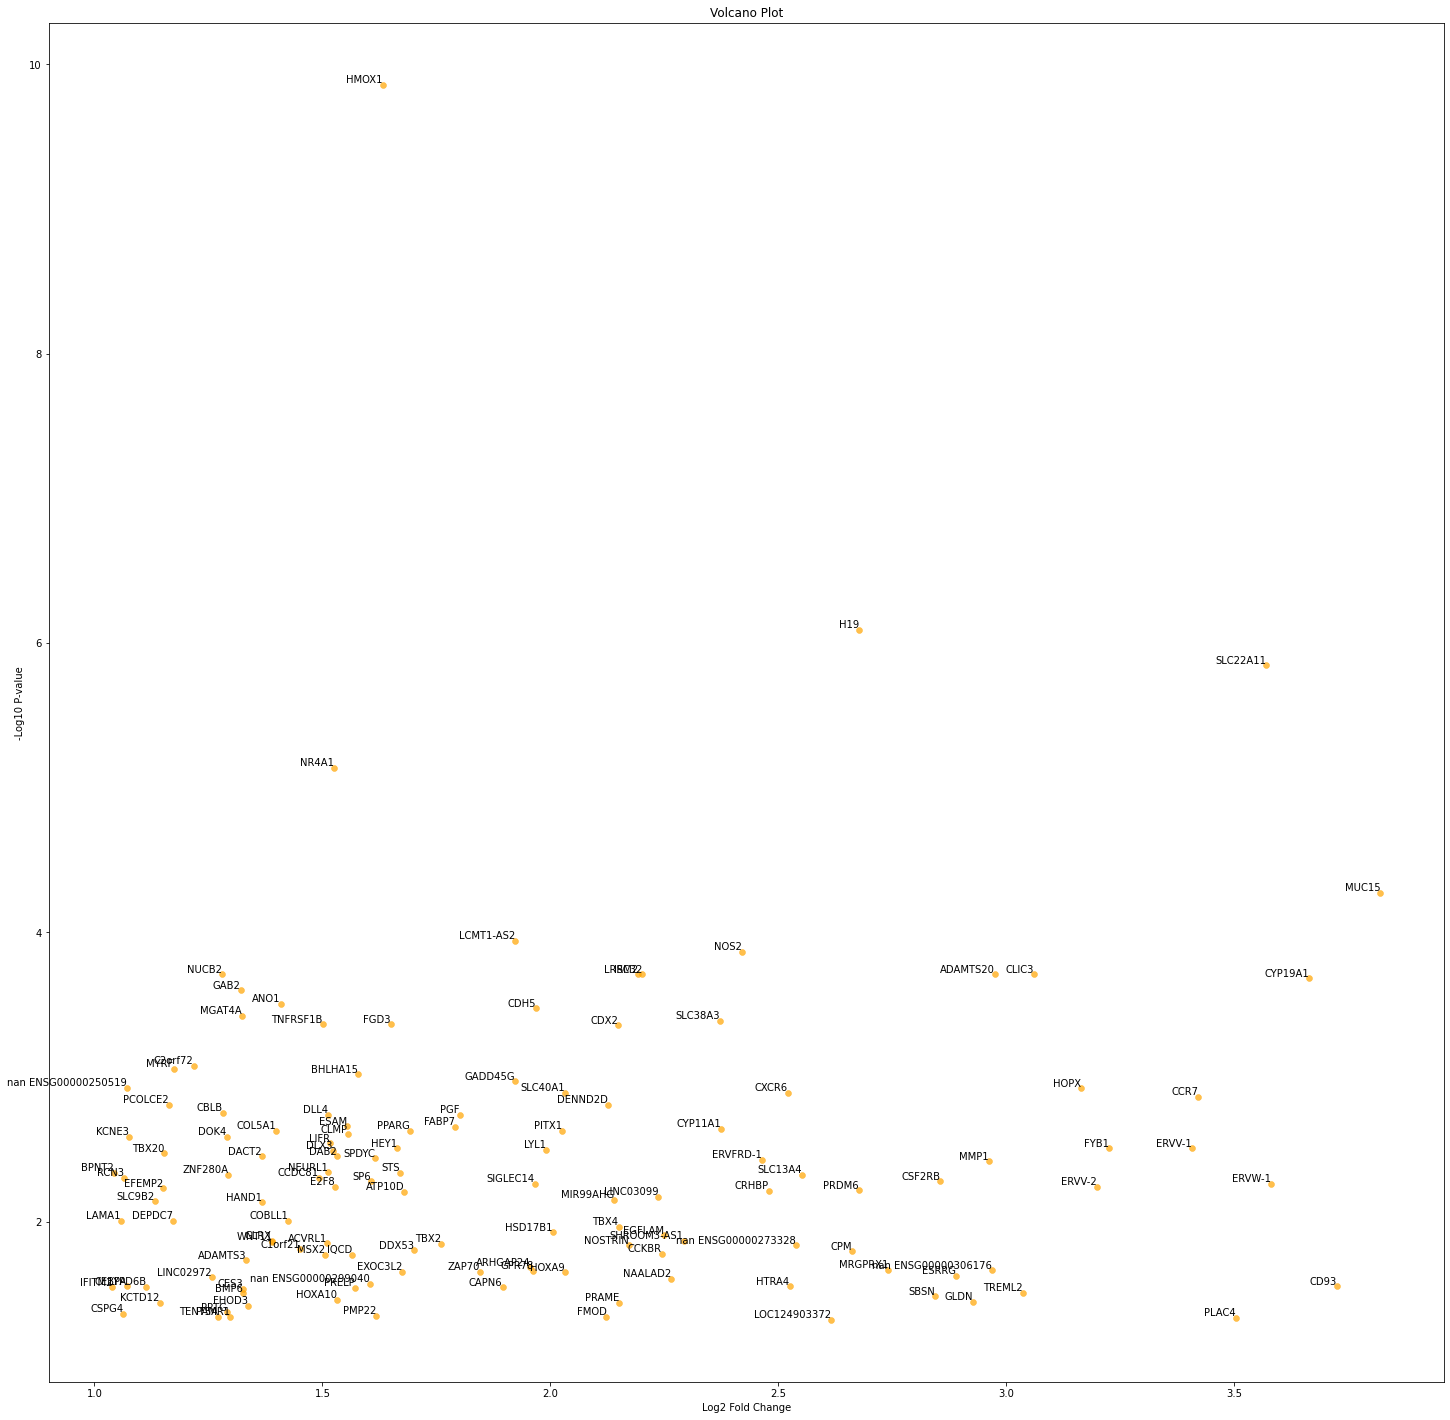

In [70]:
# Plot a only upregulated genes
res_df['significant'] = res_df['padj'] < 0.05
res_df['TwoFoldUpregulation'] = (res_df['log2FoldChange'] >= 1)
res_df['SignificantUpregulation'] = (res_df['significant'] == True) & (res_df['TwoFoldUpregulation'] == True)

res_df_SignificantUpregulation = res_df[res_df['SignificantUpregulation'] == True]

# Volcano plot
plt.figure(figsize=(25,25))
sns.scatterplot(data=res_df_SignificantUpregulation, x='log2FoldChange', y=-np.log10(res_df['padj']), edgecolor=None, alpha=0.7, color = 'orange')
#plt.xlim(-4, 4)
plt.title('Volcano Plot')
plt.xlabel('Log2 Fold Change')
plt.ylabel('-Log10 P-value')

for _, row in res_df[res_df['SignificantUpregulation']].iterrows():
    
    plt.text(row['log2FoldChange'], -np.log10(row['padj']), row['GeneID'], 
             ha='right', va='bottom', fontsize=10, alpha = 1)


plt.show()

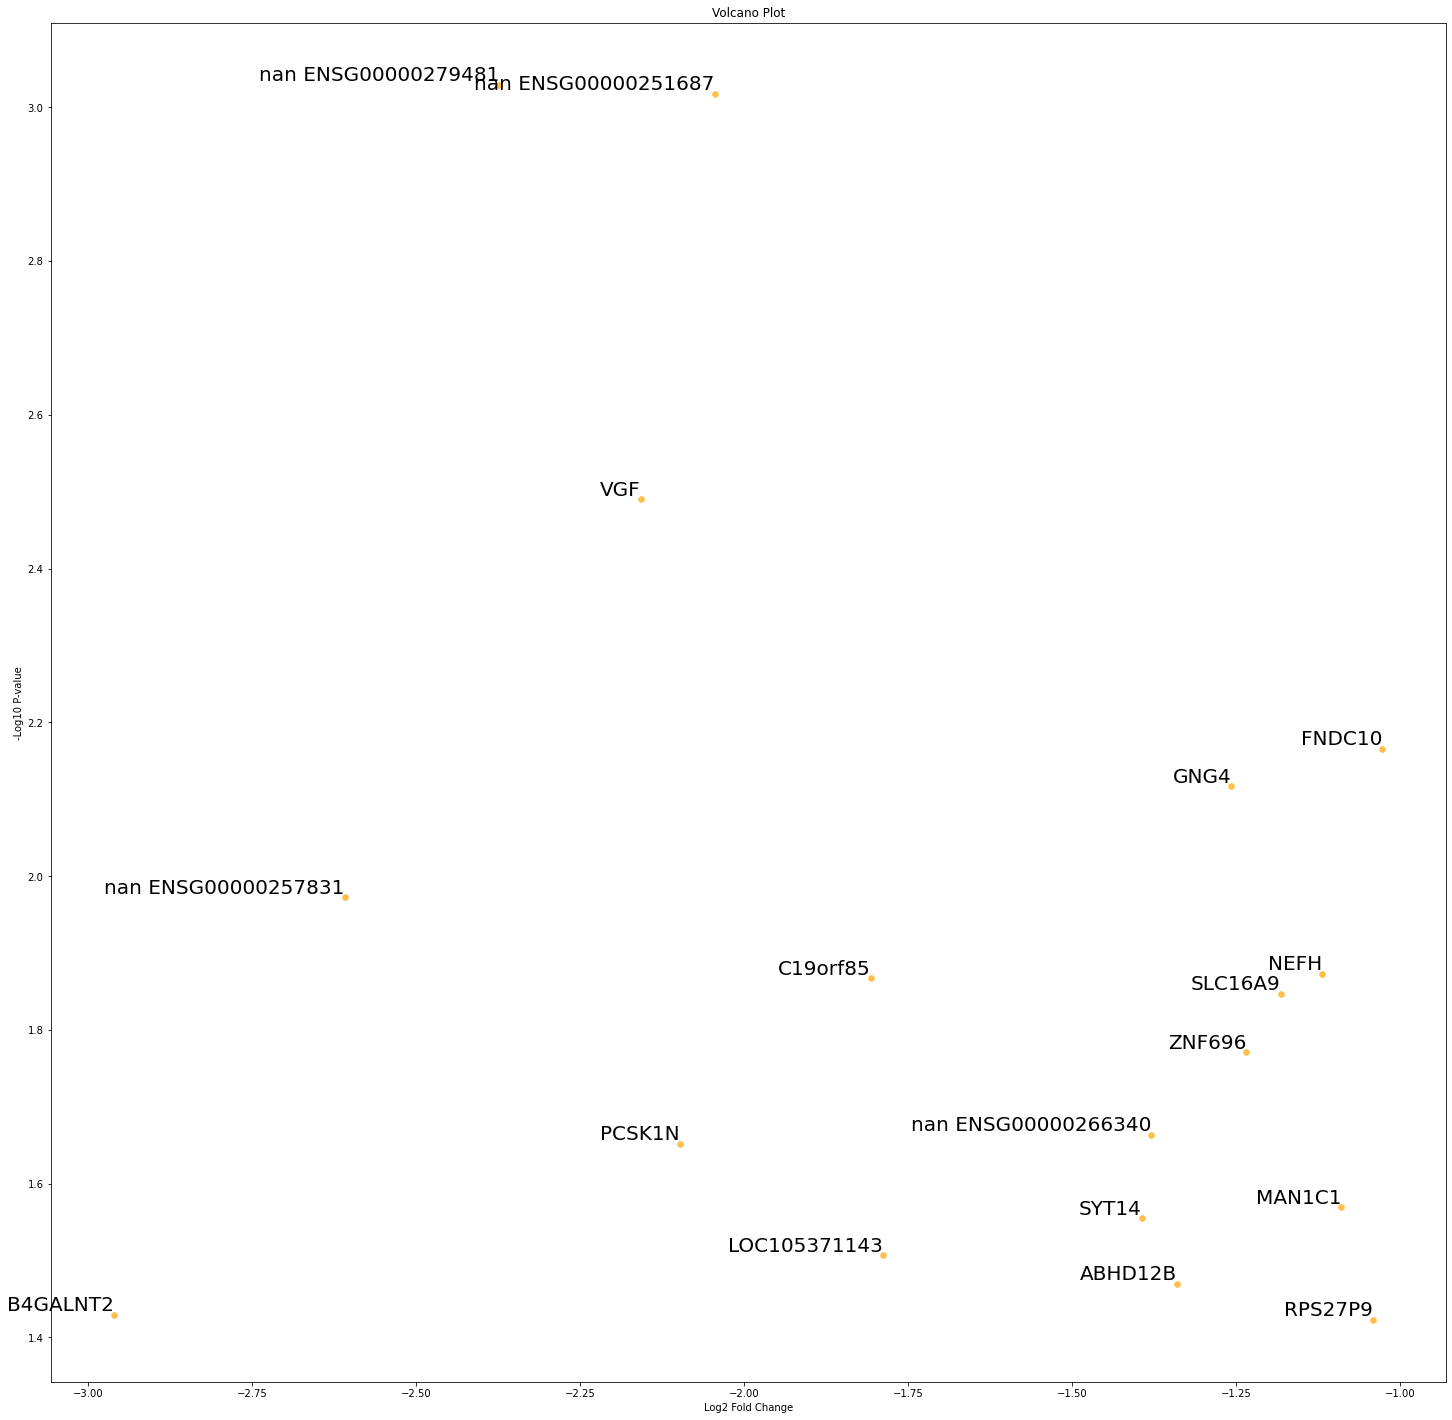

In [27]:
# Plot a only downregulated genes
res_df['significant'] = res_df['padj'] < 0.05
res_df['TwoFoldUpregulation'] = (res_df['log2FoldChange'] <= -1)
res_df['SignificantDownregulation'] = (res_df['significant'] == True) & (res_df['TwoFoldUpregulation'] == True)

res_df_SignificantDownregulation = res_df[res_df['SignificantDownregulation'] == True]

# Volcano plot
plt.figure(figsize=(25,25))
sns.scatterplot(data=res_df_SignificantDownregulation, x='log2FoldChange', y=-np.log10(res_df['padj']), edgecolor=None, alpha=0.7, color = 'orange')
#plt.xlim(-4, 4)
plt.title('Volcano Plot')
plt.xlabel('Log2 Fold Change')
plt.ylabel('-Log10 P-value')

for _, row in res_df[res_df['SignificantDownregulation']].iterrows():
    
    plt.text(row['log2FoldChange'], -np.log10(row['padj']), row['GeneID'], 
             ha='right', va='bottom', fontsize=20, alpha = 1)

plt.savefig('/Bioinformatics_D/Figures/Volcano_down_day10_R2.pdf', bbox_inches='tight', dpi=300)
plt.savefig('/Bioinformatics_D/Figures/Volcano_down_day10_R2.png', bbox_inches='tight', dpi=300)
plt.show()

In [11]:
data = {
    'Significantly down': [28, 106, 30],
    'Significantly up': [65, 242, 242]
}
index = ['Naive', 'Day 5', 'Day 10']

df_significantly_up_down_genes = pd.DataFrame(data, index=index)
df_significantly_up_down_genes

,Significantly down,Significantly up
Naive,28,65
Day 5,106,242
Day 10,30,242


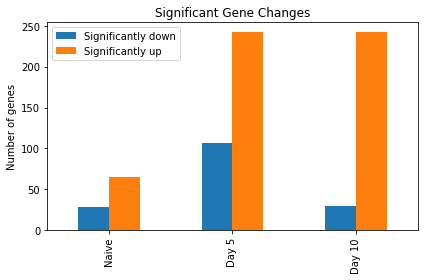

In [14]:
df_significantly_up_down_genes.plot(kind='bar')
plt.ylabel('Number of genes')
plt.title('Significant Gene Changes')
plt.tight_layout()

plt.savefig('/Bioinformatics_D/Figures/sigdown_sigup_stats.pdf', bbox_inches='tight', dpi=300)
plt.savefig('/Bioinformatics_D/Figures/sigdown_sigup_stats.png', bbox_inches='tight', dpi=300)
plt.show()